In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Dataset:
Dua, D. and Graff, C. (2019). UCI Machine Learning Repository [http://archive.ics.uci.edu/ml]. Irvine, CA: University of California, School of Information and Computer Science.

Donated by:
P. Savicky
Institute of Computer Science, AS of CR
Czech Republic
savicky '@' cs.cas.cz

In [2]:
cols = [
	"fLength",
	"fWidth",
	"fSize",
	"fConc",
	"fConc1",
	"fAsym",
	"fM3Long",
	"fM3Trans",
	"fAlpha",
	"fDist",
	"class",
]
df = pd.read_csv("data/magic04.data", names=cols)
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [ ]:
df["class"] = pd.Categorical(df["class"], categories=["g", "h"])

In [ ]:
df["class"] = df["class"].map({"g": 1, "h": 0}).astype("int8")

In [5]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


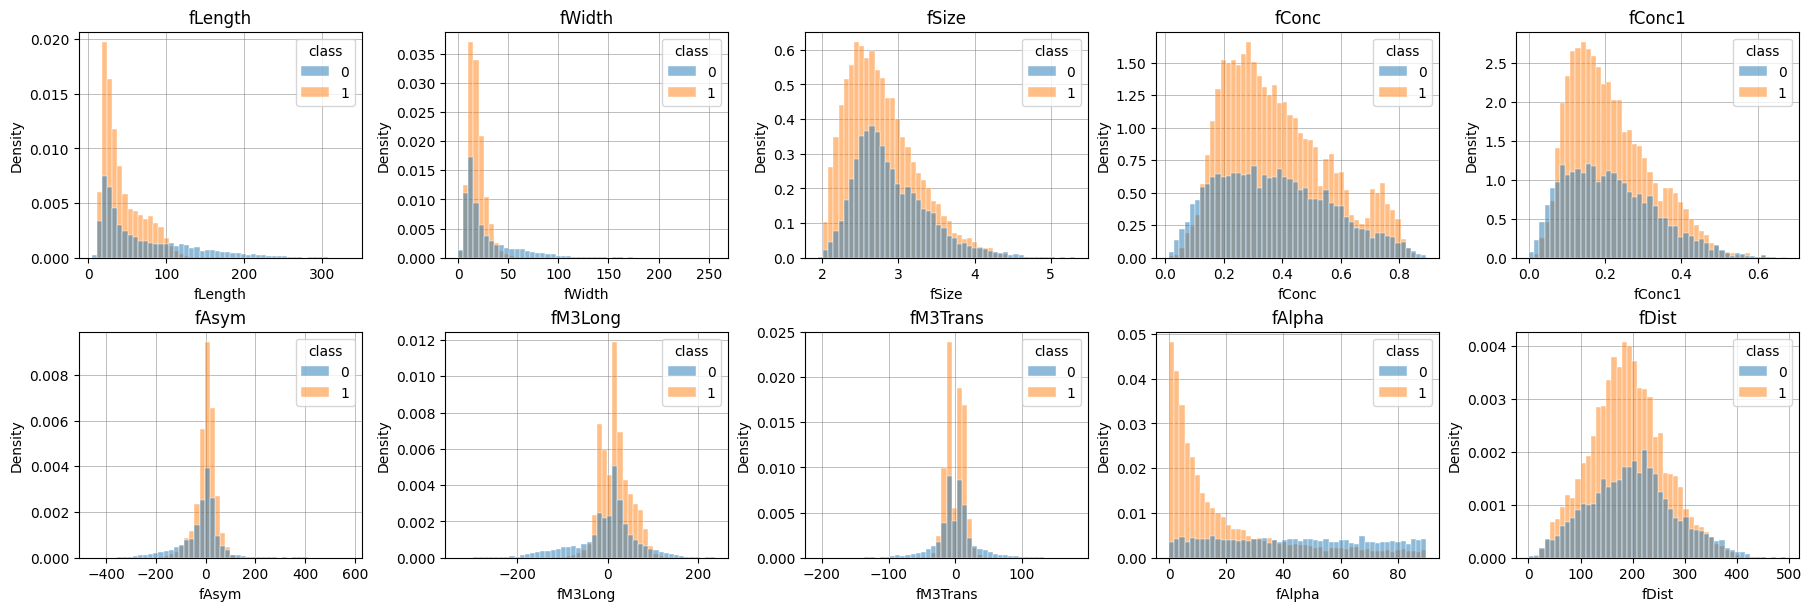

In [32]:
feature_names = cols[:-1]
num_features = len(feature_names)

# Grid size: 2 rows × 5 cols for 10 features
fig, axes = plt.subplots(2, 5, figsize=(18, 6), constrained_layout=True)
axes = axes.ravel()

for axis, feature in zip(axes, feature_names):
	sns.histplot(
		data=df,
		x=feature,
		hue="class",
		hue_order=[0, 1],
		stat="density",
		bins=50,
		alpha=0.5,
		edgecolor="white",
		linewidth=0.3,
		ax=axis,
	)
	axis.set_title(feature)
	axis.set_xlabel(feature)
	axis.set_ylabel("Density")
	axis.grid(True, alpha=0.6, linewidth=0.6, color="grey")
	axis.set_axisbelow(True)

# Single, consistent legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ["hadron (0)", "gamma (1)"], loc="upper right", frameon=False)
plt.show()


# Train, validation, test datasets

In [ ]:
df_shuffled = df.sample(frac=1.0, random_state=42)

In [ ]:
n_samples = len(df_shuffled)
train_end = int(0.6 * n_samples)
valid_end = int(0.8 * n_samples)

# Partition into sets.
train = df_shuffled.iloc[:train_end].reset_index(drop=True)
valid = df_shuffled.iloc[train_end:valid_end].reset_index(drop=True)
test = df_shuffled.iloc[valid_end:].reset_index(drop=True)

In [ ]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler


def scale_dataset(dataframe, oversample=False) -> tuple:
	X = dataframe[dataframe.columns[:-1]].values
	y = dataframe[dataframe.columns[-1]].values

	scaler = StandardScaler()
	X = scaler.fit_transform(X)

	if oversample:
		ros = RandomOverSampler()
		X, y = ros.fit_resample(X, y)

	data = np.hstack((X, np.reshape(y, (-1, 1))))

	return data, X, y

In [ ]:
train_data, X_train, y_train = scale_dataset(train, oversample=True)
valid_data, X_valid, y_valid = scale_dataset(valid, oversample=False)
test_data, X_test, y_test = scale_dataset(test, oversample=False)

## KNN

In [ ]:
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [ ]:
y_pred = knn_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.73      0.73      1331
           1       0.86      0.85      0.85      2473

    accuracy                           0.81      3804
   macro avg       0.79      0.79      0.79      3804
weighted avg       0.81      0.81      0.81      3804



## Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
nb_model = GaussianNB()
nb_model = nb_model.fit(X_train, y_train)

In [ ]:
y_pred = nb_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.39      0.49      1331
           1       0.73      0.89      0.80      2473

    accuracy                           0.72      3804
   macro avg       0.69      0.64      0.65      3804
weighted avg       0.70      0.72      0.69      3804



## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lg_model = LogisticRegression()
lg_model = lg_model.fit(X_train, y_train)

In [ ]:
y_pred = lg_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.71      0.69      1331
           1       0.84      0.81      0.82      2473

    accuracy                           0.78      3804
   macro avg       0.75      0.76      0.76      3804
weighted avg       0.78      0.78      0.78      3804



## Support-Vector Classification (SVC)

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_model = SVC()
svm_model = svm_model.fit(X_train, y_train)

In [ ]:
y_pred = svm_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.78      0.79      1331
           1       0.88      0.90      0.89      2473

    accuracy                           0.86      3804
   macro avg       0.84      0.84      0.84      3804
weighted avg       0.86      0.86      0.86      3804



### Neural Networks 

In [ ]:
import tensorflow as tf

In [ ]:
def plot_history(history):
	fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
	ax1.plot(history.history["loss"], label="loss")
	ax1.plot(history.history["val_loss"], label="val_loss")
	ax1.set_xlabel("Epoch")
	ax1.set_ylabel("Binary crossentropy")
	ax1.grid(True)

	ax2.plot(history.history["accuracy"], label="accuracy")
	ax2.plot(history.history["val_accuracy"], label="val_accuracy")
	ax2.set_xlabel("Epoch")
	ax2.set_ylabel("Accuracy")
	ax2.grid(True)

	plt.show()

In [31]:
def train_model(
	X_train, y_train, num_nodes, dropout_prob, lr, batch_size, epochs
) -> tuple:
	nn_model = tf.keras.Sequential([
		tf.keras.layers.Input(shape=(10,)),
		tf.keras.layers.Dense(num_nodes, activation="relu"),
		tf.keras.layers.Dropout(dropout_prob),
		tf.keras.layers.Dense(num_nodes, activation="relu"),
		tf.keras.layers.Dropout(dropout_prob),
		tf.keras.layers.Dense(1, activation="sigmoid"),
	])

	nn_model.compile(
		optimizer=tf.keras.optimizers.Adam(lr),
		loss="binary_crossentropy",
		metrics=["accuracy"],
	)

	history = nn_model.fit(
		X_train,
		y_train,
		epochs=epochs,
		batch_size=batch_size,
		validation_split=0.2,
		verbose=0,
	)

	return nn_model, history

In [ ]:
least_val_loss = float("inf")
least_loss_model = None
epochs = 100
for num_nodes in [16, 32, 64]:
	for dropout_prob in [0, 0.2]:
		for lr in [0.01, 0.005, 0.001, 0]:
			for batch_size in [16, 32, 64, 128]:
				print(
					f"{num_nodes} nodes, dropout {dropout_prob}, lr {lr}, batch size {batch_size}"
				)
				model, history = train_model(
					X_train=X_train,
					y_train=y_train,
					num_nodes=num_nodes,
					dropout_prob=dropout_prob,
					lr=lr,
					batch_size=batch_size,
					epochs=epochs,
				)
				plot_history(history=history)
				val_loss = model.evaluate(X_valid, y_valid)
				if val_loss < least_val_loss:
					least_val_loss = val_loss
					least_loss_model = model

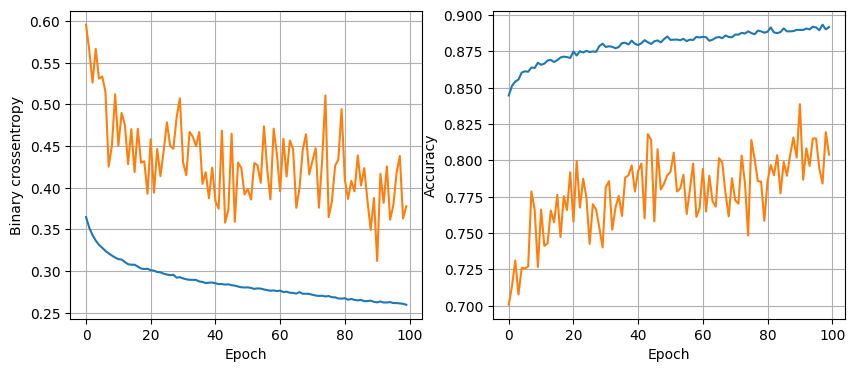

In [ ]:
plot_history(history)